In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv("/home/wieger/Documents/Research/Omnisketch/omni/output/pointQueries/CAIDA/results_Test_two_LHS_CAIDA_2024-02-26 10:47:18_Rep2.csv")

In [6]:
def add_condition(df):
    df['condition'] = df['numPredicates']*3*31*32*32/(0.001*df['RAM'])
    df['satCondition'] = ((df['intersectionSizeOfR']/df['unionSizeOfR']) >= df['condition'])
    return df

In [7]:
def thrK(pars, numAttr):
    f = pars.replace('[', '').replace(']','').split(', ')
    d = int(f[0])
    w = int(f[1])
    K = int(f[2])
    thrK = d * w * K * numAttr
    return thrK
    
thrK(df['parameters'].iloc[1], 5)

2160

In [11]:
def preprocess(df):
    df = add_condition(df)
    df['RAM (MB)'] = df['RAM']/(8e6)
    df['UsedRAM'] = df['memUsageSynopsis']/(8e6)
    df['sampleTypeDel'] = df['sampleType'] + "_" + df['TwoKmin'].astype('str')
    df['type'] = df['sampleTypeDel'] + "_" + df['noiseUpdates'].astype('str')
    df1 = df
    df1['thrK'] = 0
    for i in range(len(df['parameters'])):
        thr_k = thrK(df['parameters'].iloc[i], 5)
        if (df1['sampleType'].iloc[i] == 'Kmin'):
            df1['thrK'].iloc[i] = thr_k
    #df1 = df1[df1['noiseUpdates'] != df1['noiseUpdates'].min()]
    #df1 = df1[df1['exactAnswer'] > 10000]
    #df1 = df1[df1['estimate'] > 0]
    
    
    return df1

In [12]:
df1 = preprocess(df)

/tmp/ipykernel_13482/2888041289.py:12: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df1['thrK'].iloc[i] = thr_k


In [14]:
df_2lhs = df1[df1['sampleType'] == 'TWOLHS']

In [20]:
df_2lhs_0 = df_2lhs[df_2lhs['noiseUpdates'] == df['noiseUpdates'].min()]
df_2lhs_01 = df_2lhs[df_2lhs['noiseUpdates'] == df['noiseUpdates'].unique()[1]]
df_2lhs_09 = df_2lhs[df_2lhs['noiseUpdates'] == df['noiseUpdates'].unique()[0]]

In [41]:
start_01 = 3000
start_0 = 6000
for k, v in df_2lhs_09.iterrows():
    row_01 = df_2lhs_01.iloc[(k%1000),:]
    row_0 = df_2lhs_0.iloc[(k%1000),:]
    text_09 = v['queryText']
    text_01 = row_01['queryText']
    text_0 = row_0['queryText']
    
    if (text_09 != text_01):
        print(k, text_09, text_01)
        break
    elif (text_09 != text_0):
        print(k, text_09, text_0)
        break
    elif (text_01 != text_0):
        print(k, text_01, text_0)
        break
        if 'ipProto' in v['queryText']:
            if '6' not in v['queryText']:
                print(v['queryText'])

    

['TWOLHS_False' 'Kmin_False' 'Kmin_True']


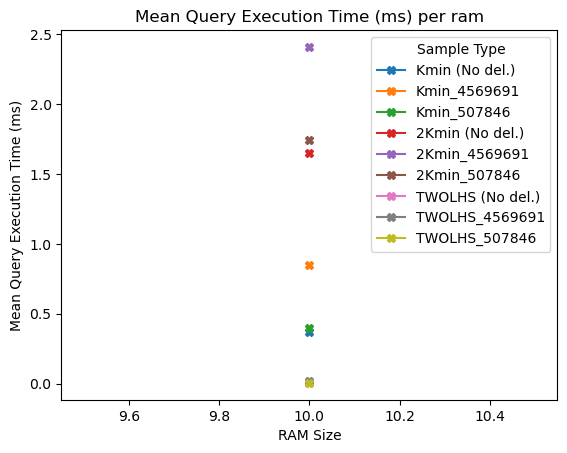

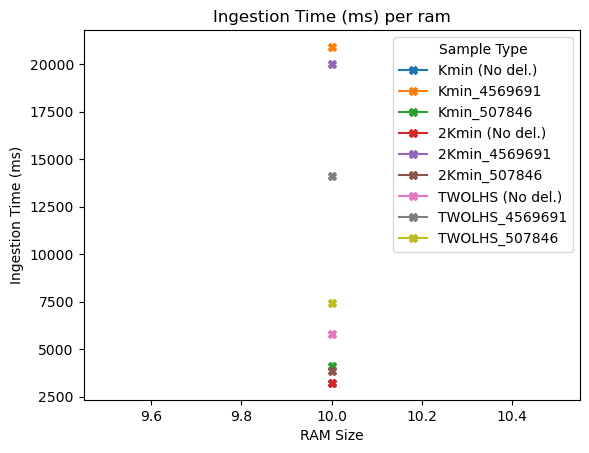

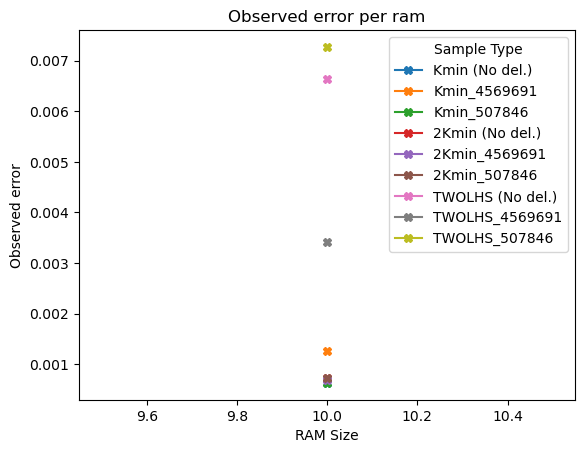

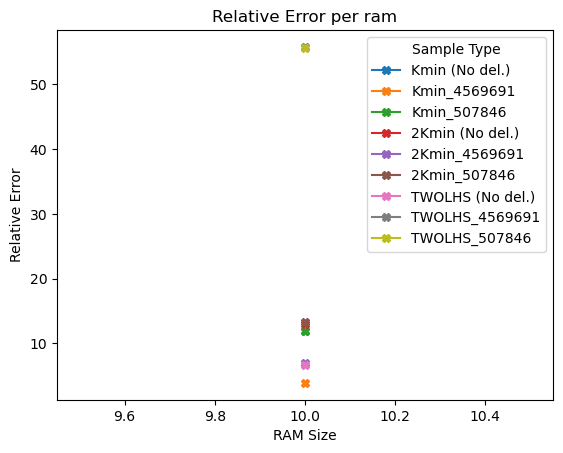

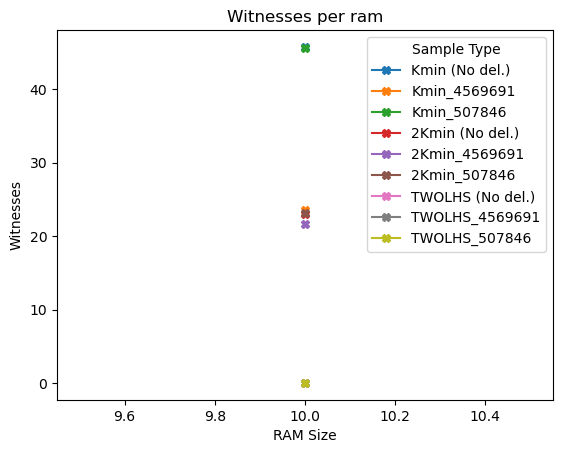

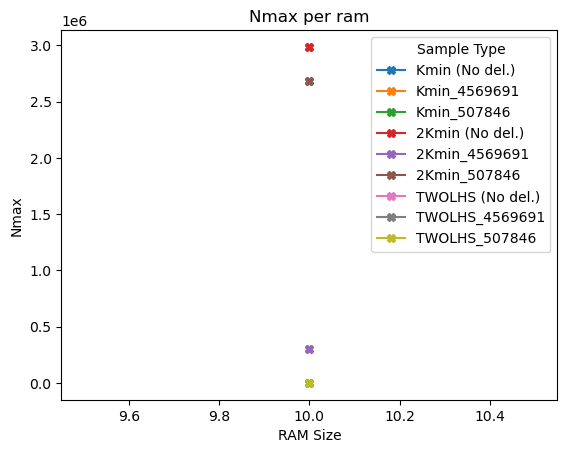

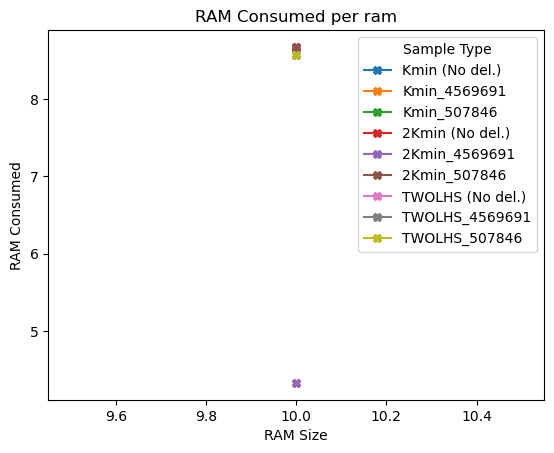

In [39]:
def plot_obs_error(df, x_, title):
    df_subset = df[['type', 'RAM (MB)', x_]]

    # Group by 'sampleType' and 'RAM' and calculate the mean observed error for each group
    grouped_df = df_subset.groupby(['type', 'RAM (MB)']).mean().reset_index()

    # Plot a line for each 'sampleType'
    for sample_type, group in grouped_df.groupby('type'):
        plt.plot(group['RAM (MB)'], group[x_], label=sample_type.replace(
            "_0"," (No del.)").replace(
            "_2688017"," (10% del.)").replace(
            "_24187156", " (90% del.)").replace(
            "_False","").replace(
            "Kmin_True", "2Kmin"), marker = "X")

    # Add labels and legend
    plt.xlabel('RAM Size')
    plt.ylabel(title)
    plt.title("{} per ram".format(title))
    plt.legend(title='Sample Type')

    # Show the plot
    plt.show()

unq_sample_types = df['sampleTypeDel'].unique()
print(unq_sample_types)
#for i in unq_sample_types:
    #dfi = df[df['sampleTypeDel'] == i]
dfi = df#[df['sampleTypeDel'] != unq_sample_types[2]]
#dfi = dfi[dfi['noiseUpdates'] == 0]
plot_obs_error(dfi, 'estTime', 'Mean Query Execution Time (ms)')
plot_obs_error(dfi, 'Avg Update Time', 'Ingestion Time (ms)')
#df1 = df_kmin[df_kmin['RAM (MB)'] >= 10]
plot_obs_error(dfi, 'epsError', 'Observed error')
#df1 = dfi[dfi['RAM (MB)'] > 10]
plot_obs_error(dfi, 'relError', 'Relative Error')
plot_obs_error(dfi, 'SCap', 'Witnesses')
plot_obs_error(dfi, 'NMax', 'Nmax')
plot_obs_error(dfi, 'UsedRAM', 'RAM Consumed')